In [1]:
%cd ..
import re
import os
from PIL import Image
from models.navidriveVLM import NaviDriveVLM
from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

/home/ximeng/anaconda3/envs/dllm/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/ximeng/Documents/NaviDrive


In [2]:
driver_model_id = "Ximeng0831/NaviDrive-Qwen3-VL-2B-SFT"
model = NaviDriveVLM(driver_model_id = driver_model_id)

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

In [3]:
sample_index = 637 # Available: [41, 100, 120, 323, 558, 637, 1483]

In [4]:
ds = load_dataset("Ximeng0831/NaviDrive-Reasoning", "qwen_32b", split="validation")
data = ds[sample_index]

In [5]:

camera_files = ["CAM_BACK", "CAM_BACK_LEFT", "CAM_FRONT_LEFT", "CAM_FRONT", "CAM_FRONT_RIGHT", "CAM_BACK_RIGHT"]
# Load images: demo figures are stored in ./figures
img_folder = f"figures/{sample_index}"
images = []
for filename in camera_files:
    filename = f"{filename}.jpg"
    img_path = os.path.join(img_folder, filename)
    img = Image.open(img_path).convert('RGB')
    images.append(img)

In [6]:
def filter_to_xy_str(original_str):
    pattern = r"\(([^)]+)\)"
    matches = re.findall(pattern, original_str)
    return ", ".join([f"({p.split(',')[0].strip()}, {p.split(',')[1].strip()})" if len(p.split(',')) > 2 else f"({p})" for p in matches])

In [7]:
ego_status_prompt = (
    "Current Dynamics:\n"
    f"- Velocity: {data['vel_val']:.2f} m/s\n"
    f"- Yaw Rate: {data['yr_val']:.2f} rad/s\n"
    f"- Acceleration (Longitudinal x, Lateral y): {data['acc_val']}\n"
    f"Past Trajectory (2Hz): {filter_to_xy_str(data['wp_past'])}\n"
    f"High-level Command: {data['command']}\n\n"
)

In [8]:
navi_user_prompt = (
                    "Inputs: 6 images (Full Surround View) and Ego-Vehicle Status.\n"
                    "1:BACK, 2:BACK_LEFT, 3:FRONT_LEFT, 4:FRONT, 5:FRONT_RIGHT, 6:BACK_RIGHT,.\n"
                    f"{ego_status_prompt}"
                    "Task: Analyze the current situation and provide the safest next action with reasons."
                    )

In [9]:
driver_user_prompt = (
                    f"{ego_status_prompt}"
                    "Predict the next 12 waypoints: (x1, y1), (x2, y2), ..., (x12, y12)."
                    )

In [10]:
reason, all_pred_waypoints = model(navi_user_prompt, driver_user_prompt, images)

In [11]:
print(reason)

Perception: The vehicle is moving straight on a wet urban street with moderate traffic. Rain is reducing visibility and affecting road traction. Pedestrians and parked vehicles are visible on both sides, with no immediate dynamic hazards in the direct path.

Action: Maintain current speed and lane position, increase following distance, and prepare for potential braking.

Reasoning: The wet road conditions require increased stopping distance. While there are no immediate hazards, the rain reduces traction and visibility, necessitating a cautious approach. Keeping the vehicle straight aligns with the command, but readiness to brake for sudden stops or pedestrian crossings is critical.


In [12]:
for i in range(len(all_pred_waypoints)):
    print(f"Waypoint {i+1}: {all_pred_waypoints[i]}")

Waypoint 1: [[4.28, -0.03], [8.53, -0.06], [12.8, -0.09], [17.04, -0.13], [21.27, -0.16], [25.52, -0.21], [29.75, -0.25], [33.97, -0.3], [38.16, -0.36], [42.33, -0.42], [46.52, -0.49], [50.66, -0.55]]
Waypoint 2: [[4.3, -0.02], [8.71, -0.03], [13.15, -0.03], [17.58, -0.03], [21.96, -0.02], [26.3, -0.02], [30.65, -0.02], [35.0, -0.02], [39.34, -0.01], [43.67, -0.0], [48.04, -0.0], [52.41, -0.0]]
Waypoint 3: [[4.28, -0.03], [8.55, -0.05], [12.84, -0.06], [17.06, -0.06], [21.33, -0.04], [25.55, -0.02], [29.79, 0.0], [34.04, 0.01], [38.3, 0.03], [42.56, 0.03], [46.84, 0.03], [51.13, 0.02]]
Waypoint 4: [[4.25, -0.03], [8.52, -0.06], [12.74, -0.11], [17.04, -0.17], [21.36, -0.23], [25.69, -0.28], [30.05, -0.33], [34.44, -0.39], [38.79, -0.46], [43.22, -0.52], [47.67, -0.58], [52.16, -0.64]]
Waypoint 5: [[4.33, -0.03], [8.7, -0.06], [13.07, -0.1], [17.54, -0.13], [21.99, -0.15], [26.49, -0.18], [30.95, -0.21], [35.39, -0.24], [39.82, -0.27], [44.22, -0.29], [48.63, -0.31], [53.01, -0.34]]
Way

In [13]:
print("Ground Truth: ", filter_to_xy_str(data['wp_future']))

Ground Truth:  (4.27, -0.03), (8.63, -0.06), (13.07, -0.09), (17.49, -0.10), (21.95, -0.11), (26.37, -0.13), (30.82, -0.14), (35.28, -0.13), (39.72, -0.13), (44.17, -0.15), (48.80, -0.16), (53.32, -0.16)


In [14]:
def plot_gt_and_pred(gt_str, pred_wp=None):
    pattern = r"\(([-+]?\d*\.?\d+)\s*,\s*([-+]?\d*\.?\d+)\s*,\s*([-+]?\d*\.?\d+)\)"
    matches = re.findall(pattern, gt_str)
        
    gt_wp = np.array([[float(val) for val in m] for m in matches])
    gt_x = np.insert(gt_wp[:, 0], 0, 0.0)
    gt_y = np.insert(gt_wp[:, 1], 0, 0.0)
    
    plt.figure(figsize=(12, 6))
    
    plt.plot(0, 0, marker='*', color='red', markersize=15, label='Ego', zorder=5)
    
    # Ground Truth
    plt.plot(gt_x, gt_y, marker='s', color='green', linewidth=3, markersize=6, alpha=0.5, label='GT', zorder=4)
    
    # Prediction
    if pred_wp is not None:
        ades = []
        for i, traj in enumerate(pred_wp):
            traj_np = np.array(traj)
            if traj_np.size > 0:
                distances = np.linalg.norm(traj_np[:, :2] - gt_wp[:, :2], axis=1)
                ade = np.mean(distances)
                ades.append(ade)
                traj_x = np.insert(traj_np[:, 0], 0, 0.0)
                traj_y = np.insert(traj_np[:, 1], 0, 0.0)
                plt.plot(traj_x, traj_y, marker='o', markersize=4, 
                         linestyle='--', alpha=0.6, label=f'Pred{i+1}')

    best_idx = np.argmin(ades) if ades else -1
    best_wp = np.array(pred_wp[best_idx])
    
    plt.title('Ground Truth vs Prediction', fontsize=14)
    plt.xlabel('X - Forward Distance (m)', fontsize=12)
    plt.ylabel('Y - Lateral Distance (m)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axis('equal')

    plt.legend(bbox_to_anchor=(1.05, 1), loc='best')
    plt.tight_layout()
    plt.show()
    
    return best_wp, gt_wp

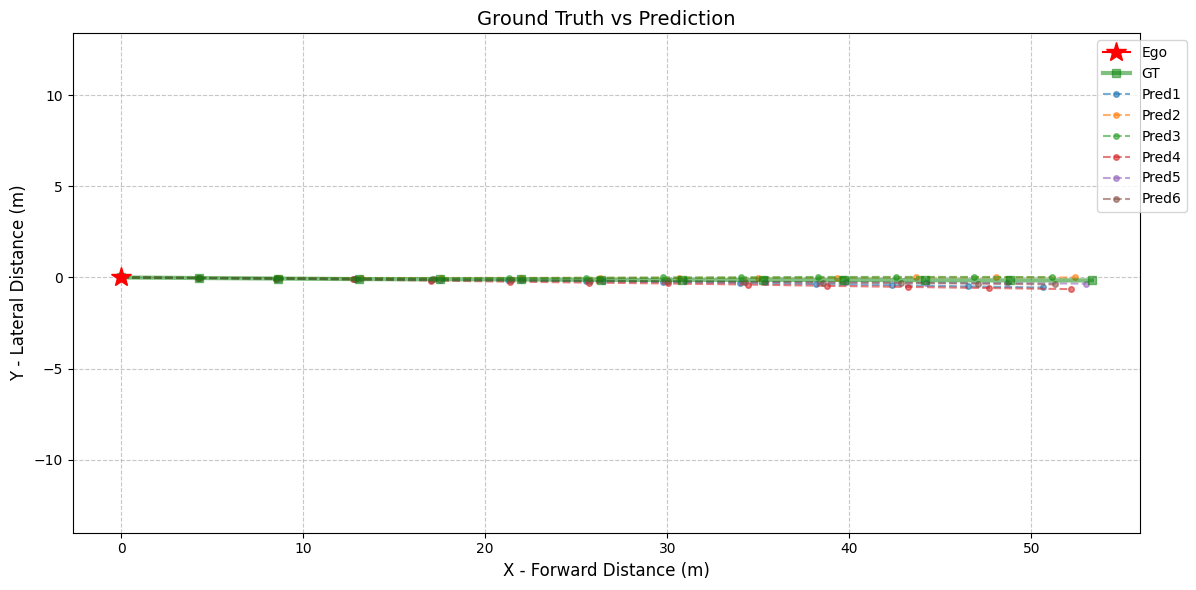

In [15]:
best_wp, gt_wp = plot_gt_and_pred(data['wp_future'], all_pred_waypoints)

In [16]:
from utils.results_utils import project_wp_to_image
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(version='v1.0-trainval', dataroot='/home/ximeng/Dataset/nuscenes_full_v1_0/', verbose=False)

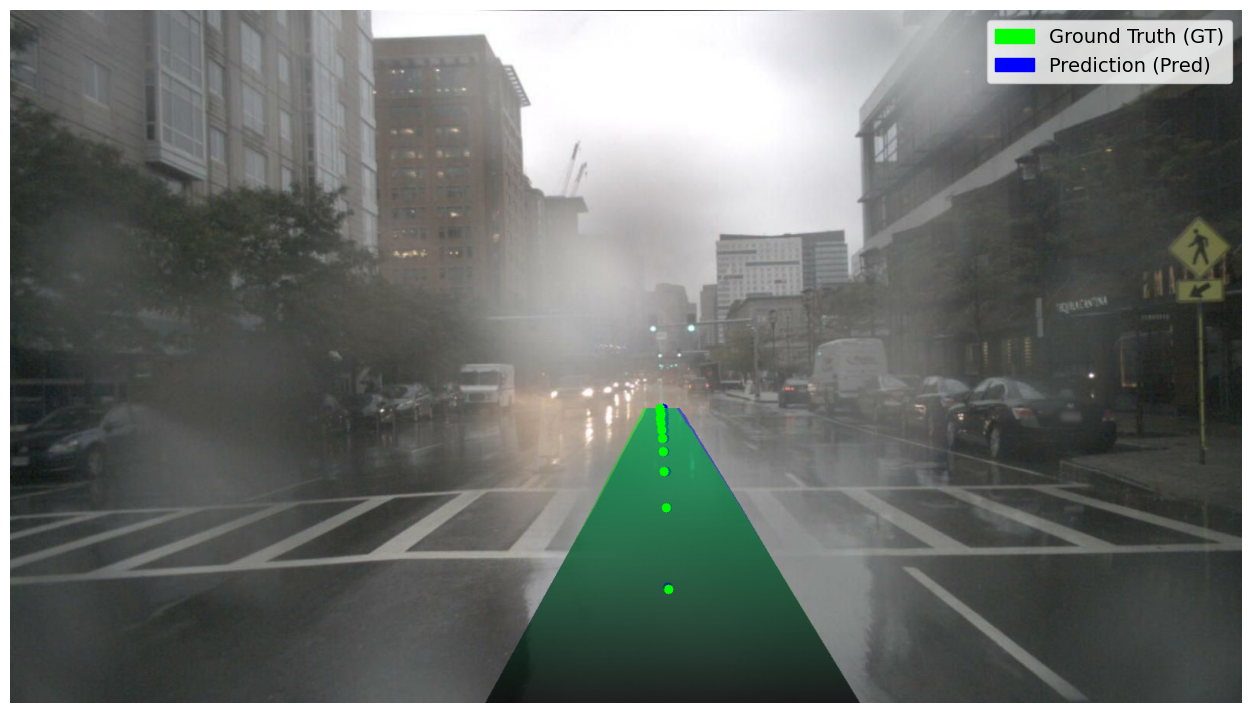

In [17]:
token = data['token'][0]
img_np = np.array(images[3])
vis_img = project_wp_to_image(nusc, token, best_wp, img_np, color_waypoints=(0, 0, 255), color_polygon=(0, 0, 255))
vis_img = project_wp_to_image(nusc, token, gt_wp, vis_img, color_waypoints=(0, 255, 0), color_polygon=(0, 255, 0))
plt.figure(figsize=(16, 9))
gt_patch = mpatches.Patch(color=(0, 1, 0), label='Ground Truth (GT)')
pred_patch = mpatches.Patch(color=(0, 0, 1), label='Prediction (Pred)')
plt.legend(handles=[gt_patch, pred_patch], loc='upper right', fontsize=14, framealpha=0.8)
plt.axis('off')
plt.imshow(vis_img)

In [ ]:
print(reason)

Perception: The vehicle is moving straight on a wet urban street with moderate traffic. Rain is reducing visibility and affecting road traction. Pedestrians and parked vehicles are visible on both sides, with no immediate dynamic hazards in the direct path.

Action: Maintain current speed and lane position, increase following distance, and prepare for potential braking.

Reasoning: The wet road conditions require increased stopping distance. While there are no immediate hazards, the rain reduces traction and visibility, necessitating a cautious approach. Keeping the vehicle straight aligns with the command, but readiness to brake for sudden stops or pedestrian crossings is critical.


: 